# Протокол для стандартизации данных с помощью библиотеки chython и RDKit

**Стандартизация включает:**
- удаление смесей, неорганических и металлоорганических соединений
- конвертация структур, удаление солей и выбор состояния ионизации
- нормализация специфических хемотипов, резонансных форм и таутомеров
- анализ химических структур при помощи интерактивной графики


## Стандартизация с помощью библиотеки chython

In [1]:
from rdkit import Chem
from rdkit.Chem import rdchem
from chython import smiles, SDFRead
import pandas as pd
from collections import Counter
import numpy as np

/opt/miniconda3/envs/cheminfo/lib/python3.9/site-packages/py_mini_racer/py_mini_racer.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exception ignored in: <function MiniRacer.__del__ at 0x117c26ca0>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/cheminfo/lib/python3.9/site-packages/py_mini_racer/py_mini_racer.py", line 315, in __del__
    self.ext.mr_free_context(getattr(self, "ctx", None))
AttributeError: 'NoneType' object has no attribute 'mr_free_context'


### Реализация в ООП

In [20]:
class MoleculeStandardizer:
    RUSSIAN_MAPPING = {
        'initial_molecules_count': "Исходное количество молекул",
        'initial_smiles_count': "Исходное количество прочитанных SMILES",
        'inorganic_molecules_count': "Количество отсеянных неорганических молекул",
        'number_canonicalize_error': "Количество ошибок нормализации хемотипов",
        'molecules_isotopes_count': "Количество молекул с убранными изотопными метками",
        'molecules_coordination_count': "Количество молекул с координационными связями",
        'metal_salts_count': "Количество разбитых металлических солей",
        'metallorganic_molecules_count': "Количество металлорганических молекул",
        'delete_mols_with_metall': "Количество отсеянной металлорганике",   
        'neutralized_molecules_count': "Количество нейтрализованных солей",
        'splitted_molecules_count': "Количество молекул с >1 связанным компонентом",
        'splitted_molecules_count_error': "Количество отсеянных молекул с >1 компонентом",
        'radical_molecules_count': "Количество отсеянных радикалов",
        'remove_acids': "Количество удаленных кислотных остатков",
        'uncorrect_chiral_count' : "Количество молекул с некорректной хиральностью",
        'uncorrect_ez_stereo': "Количество молекул с некорректными E/Z стереометками",
        'remove_stereo': "Количество молекул с удаленными стереометками",
        'mol_weight': "Большая молекулярная масса",
        'final_molecules_count': "Количество молекул после стандартизации",
        'duplicates_count': "Количество удаленных дубликатов"
    }

    METALS_SYMBOLS = {
        'Li', 'Be', 'Na', 'Mg', 'Al', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
        'Ga', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Cs', 'Ba',
        'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
        'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'Fr', 'Ra', 'Ac', 'Th', 'Pa', 'U',
        'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr'
    }
    
    def __init__(self):
        self.statistics = Counter()
        self.stand_data = []
        self.bad_smiles = []
        self.unique_smiles = dict()  # Для отслеживания уникальных SMILES
        self.types_data = None
        
    def _reset_counters(self):
        self.statistics.clear()
        self.stand_data.clear()
        self.bad_smiles.clear()
        self.unique_smiles.clear()
    
    def is_metallorganic(self, mol) -> bool:
        """Определяет, является ли молекула металлоорганической"""
        atoms = {a.atomic_symbol for _, a in mol.atoms()}
        return bool(self.METALS_SYMBOLS & atoms)
    
    def mol_wei(self, m):
        mol_weight = sum(x.atomic_mass for x in m._atoms.values()) + sum(numb for numb in m._hydrogens.values() if numb)
        return mol_weight

    def curation_salt(self, mol, check_chirality):
        a = []
        for i in mol.connected_components:
            if len(i) < 3:
                continue
            a.append(mol.substructure(i, recalculate_hydrogens=False))
        mols = []
        for ostatok in a:
            if not check_chirality:
                atoms_with_charge = [i for i in ostatok if ostatok.atom(i).charge != 0]
                for n in atoms_with_charge:
                    ostatok.atom(n).charge = 0
            mols.append(ostatok)
        return mols.sort(key= lambda x: self.mol_wei(x), reverse=True)

    @staticmethod
    def check_all_chiral_centers_assigned(smiles_str: str) -> bool:
        """
        Проверяет, все ли хиральные центры в молекуле имеют явно заданную конфигурацию.
        
        Args:
            smiles (str): SMILES строка молекулы
            
        Returns:
            bool: True, если все хиральные центры имеют заданную конфигурацию,
                  False, если есть неопределенные центры
        """
        # print(smiles_str)
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            return False
        # Найти все хиральные центры включая неопределенные
        chiral_centers = Chem.FindMolChiralCenters(mol, force=True, includeUnassigned=True)
        
        # Проверить, есть ли неопределенные центры (отмечены как '?')
        for center in chiral_centers:
            if center[1] == '?':
                return False
        
        return True
    
    @staticmethod
    def get_substituents(atom, exclude_atom_idx, mol):
        """Возвращает канонические SMILES для заместителей атома, исключая указанный атом."""
        subs = []
        for neighbor in atom.GetNeighbors():
            if neighbor.GetIdx() == exclude_atom_idx:
                continue
            # Создаём копию молекулы и удаляем все атомы, кроме поддерева, начинающегося с neighbor
            temp_mol = Chem.RWMol(Chem.Mol(mol))
            atoms_to_keep = {neighbor.GetIdx()}
            # Рекурсивно собираем все атомы, связанные с neighbor
            def collect_subtree(atom_idx, visited):
                visited.add(atom_idx)
                for n in mol.GetAtomWithIdx(atom_idx).GetNeighbors():
                    if n.GetIdx() != exclude_atom_idx and n.GetIdx() not in visited:
                        atoms_to_keep.add(n.GetIdx())
                        collect_subtree(n.GetIdx(), visited)
            collect_subtree(neighbor.GetIdx(), {exclude_atom_idx})
            # Удаляем атомы, не входящие в поддерево
            for idx in sorted([i for i in range(temp_mol.GetNumAtoms()) if i not in atoms_to_keep], reverse=True):
                temp_mol.RemoveAtom(idx)
            # Преобразуем в SMILES
            sub_smiles = Chem.MolToSmiles(temp_mol, canonical=True)
            subs.append(sub_smiles)
        # Добавляем неявные водороды, если есть
        if atom.GetTotalNumHs() > 0:
            subs.extend(['[H]'] * atom.GetTotalNumHs())
        return subs

    def is_chiral_double_bond(self, bond, mol):
        """Проверяет, является ли двойная связь хиральной (возможна ли E/Z-изомерия)."""
        if bond.GetBondType() != rdchem.BondType.DOUBLE:
            return False
        # Проверяем, находится ли связь в малом кольце (≤ 7 атомов)
        ssr = Chem.GetSymmSSSR(mol)
        small_ring_bonds = set()
        for ring in ssr:
            if len(ring) <= 7:  # Исключаем кольца размером 7 или меньше
                for i in range(len(ring)):
                    for j in range(i + 1, len(ring)):
                        ring_bond = mol.GetBondBetweenAtoms(ring[i], ring[j])
                        if ring_bond is not None:
                            small_ring_bonds.add(ring_bond.GetIdx())
        if bond.GetIdx() in small_ring_bonds:
            return False
        # Проверяем заместители
        a1 = bond.GetBeginAtom()
        a2 = bond.GetEndAtom()
        subs1 = self.get_substituents(a1, a2.GetIdx(), mol)
        subs2 = self.get_substituents(a2, a1.GetIdx(), mol)
        # Для E/Z-изомерии нужно ровно 2 разных заместителя с каждой стороны
        return len(subs1) == 2 and len(set(subs1)) == 2 and len(subs2) == 2 and len(set(subs2)) == 2

    def check_ez_stereo(self, smiles_str: str) -> bool:
        """
        Проверяет наличие двойных связей с неуказанной E/Z-стереохимией, исключая малые кольца.
        """
        mol = Chem.MolFromSmiles(smiles_str, sanitize=True)
        if not mol:
            return False
        
        chiral_dbs = [bond for bond in mol.GetBonds() if self.is_chiral_double_bond(bond, mol)]
        
        if not chiral_dbs:
            return True
        
        ez_specified = any(bond.GetStereo() != rdchem.BondStereo.STEREONONE for bond in chiral_dbs)
        
        if ez_specified:
            return True
        else:
            return False

    def _parse_molecule(self, smiles_str):
        try:
            return smiles(
                smiles_str,
                ignore=True,
                remap=False,
                ignore_stereo=False,
                ignore_bad_isotopes=False,
                keep_implicit=True,
                ignore_carbon_radicals=False,
                ignore_aromatic_radicals=False
            )
        except Exception:
            return None

    def _process_molecule(self, idx, smiles_str, prop_value):
        mol = self._parse_molecule(smiles_str)
        if mol is None:
            self.bad_smiles.append([idx, smiles_str, prop_value, "Uncorrect SMILES"])
            return None, "Uncorrect SMILES"
        # Проверка на количество тяжелых атомов
        if sum(1 for _ in mol.atoms()) > 100:
            self.statistics['mol_weight'] += 1
            self.bad_smiles.append([idx, smiles_str, prop_value, "MW"])
            return None, "MW"
        # Проверка неорганике
        unique_atoms = {a.atomic_symbol for _, a in mol.atoms()}
        if 'C' not in unique_atoms or len(list(mol.atoms())) <= 5:
            self.statistics['inorganic_molecules_count'] += 1
            self.bad_smiles.append([idx, str(mol), prop_value, "Nonorganic"])
            return None, "Nonorganic"
        
        return mol, None

    def _process_organic(self, idx, mol, prop_value, check_chirality):
        try:
            canon_log = mol.canonicalize(fix_tautomers=True, logging=True)
            mol.meta['canonicalized'] = canon_log
        except Exception:
            self.statistics['number_canonicalize_error'] += 1
            self.bad_smiles.append([idx, str(mol), prop_value, "Cannonicalize_error"])
            return None, "Cannonicalize error"
        # Очистка изотопов
        if mol.clean_isotopes():
            self.statistics['molecules_isotopes_count'] += 1
        if mol.is_radical:
            self.statistics['radical_molecules_count'] += 1
            return None, "Radical"
        # Очистка и удаление металлорганике
        if mol.remove_coordinate_bonds():
            self.statistics['molecules_coordination_count'] += 1
        if mol.split_metal_salts(logging=True):
            self.statistics['metal_salts_count'] += 1
        if mol.remove_metals(logging=True):
            self.statistics['metallorganic_molecules_count'] += 1
        if self.is_metallorganic(mol):
            self.statistics['delete_mols_with_metall'] += 1
            self.bad_smiles.append([idx, str(mol), prop_value, "Metallorganic"])
            return None, "Metallorganic"
        # Очистка и удаление солей
        if mol.neutralize():
            self.statistics['neutralized_molecules_count'] += 1
        if mol.remove_acids():
            self.statistics['remove_acids'] += 1
        # Удаление смесей
        if mol.connected_components_count > 1:
            # Опциональное удаление зарядов
            components = self.curation_salt(mol, check_chirality)
            if not components or len(components) > 1:
                self.statistics['splitted_molecules_count_error'] += 1
                self.bad_smiles.append([idx, str(mol), prop_value, "curation salt error"])
                return None, "Salt error"
            mol = components[0]
        
        # Опциональная проверка стереохимии
        if check_chirality:
            chiral_ok = self.check_all_chiral_centers_assigned(str(mol))
            ez_ok = self.check_ez_stereo(str(mol))
            
            if not chiral_ok:
                self.statistics['uncorrect_chiral_count'] += 1
                return None, "Uncorrect chirality"
            if not ez_ok:
                self.statistics['uncorrect_ez_stereo'] += 1
                return None, "Uncorrect E/Z stereo"
        else:
            mol_before = str(mol)
            mol.clean_stereo()
            if mol_before != str(mol):
                self.statistics['remove_stereo'] += 1
        
        return mol, None

    def _check_duplicate(self, mol, idx, prop_value):
        """Проверяет и обрабатывает дубликаты с обновлением значений свойств."""
        key = bytes(mol)
        if key not in self.unique_smiles:
            # Первое вхождение: сохраняем индекс и значение
            self.unique_smiles[key] = (idx, prop_value)
            return False

        # Дубликат найден
        old_idx, old_value = self.unique_smiles[key]

        # Для категориальных данных всегда удаляем дубликат
        if not self.types_data:
            self.statistics['duplicates_count'] += 1
            self.bad_smiles.append([idx, str(mol), prop_value, "Duplicate"])
            return True

        # Для числовых данных проверяем разницу в log единицах
        try:
            log_old = np.log10(old_value)
            log_new = np.log10(prop_value)
            diff = abs(log_old - log_new)
        except (ValueError, TypeError):  # Обработка нечисловых/неположительных значений
            self.statistics['duplicates_count'] += 1
            self.bad_smiles.append([idx, str(mol), prop_value, "Duplicate"])
            return True

        if diff > 0.2:  # Разница слишком большая - удаляем дубликат
            self.statistics['duplicates_count'] += 1
            self.bad_smiles.append([idx, str(mol), prop_value, "Duplicate"])
            return True
        else:
            # Вычисляем среднее геометрическое
            new_value = 10 ** ((log_old + log_new) / 2)
            # Обновляем запись для оригинальной молекулы
            self.unique_smiles[key] = (old_idx, new_value)
            # Обновляем значение в result_df
            # self.unique_smiles[ke] = new_value
            self.statistics['duplicates_count'] += 1
            self.bad_smiles.append([idx, str(mol), prop_value, "Duplicate"])
            return True

    def standardize(self, data: pd.DataFrame, target: str, check_chirality: bool = False):
        if not isinstance(data, pd.DataFrame):
            raise TypeError('Требуется объект pd.DataFrame')
        
        self._reset_counters()
        total = len(data)
        result_df = data.copy()
        result_df['ready_SMILES'] = None
        result_df['filter_status'] = None
        result_df['property'] = None
        if data[target].nunique() > 2:
            self.types_data = True
        for i, idx in enumerate(data.index):
            
            smiles_str, prop_value = data.loc[idx, :]
            
                
            self.statistics['initial_molecules_count'] += 1
            
            if i % 1000 == 0:
                print(f"Обработано: {i}/{total}")
            
            mol, status = self._process_molecule(idx, smiles_str, prop_value)
            if mol is None:
                result_df.at[idx, 'filter_status'] = status
                continue
                
            processed_mol, status = self._process_organic(idx, mol, prop_value, check_chirality)
            if processed_mol is None:
                result_df.at[idx, 'filter_status'] = status
                continue
                
            # Проверка на дубликат
            if self._check_duplicate(processed_mol, idx, prop_value):
                result_df.at[idx, 'filter_status'] = "Duplicate"
                continue
                
            # processed_mol.meta['Property value'] = self.unique_smiles[bytes(mol)][1]
            processed_mol.meta['ID'] = idx
            self.stand_data.append(processed_mol)
            self.statistics['final_molecules_count'] += 1
            result_df.at[idx, 'ready_SMILES'] = str(processed_mol)
            # result_df.at[idx, 'property'] = processed_mol.meta['Property value']
        
        for (idx, prop_value) in self.unique_smiles.values():
            result_df.at[idx, 'property'] = prop_value
        
        # Формирование отчета
        report_df = pd.DataFrame({
            'Критерий': list(self.RUSSIAN_MAPPING.values()),
            'Результат': [self.statistics.get(key, 0) for key in self.RUSSIAN_MAPPING ]
        })
        
        return report_df, self.stand_data, self.bad_smiles, result_df

### Реализация функционально 

In [2]:
def is_metallorganic(mol) -> bool:
    """Проверяет, является ли соединение металлоорганическим."""
    for _, atom in mol.atoms():  # Распаковываем кортеж (индекс, атом)
           if atom.atomic_symbol in metals_symbols:
               return True
    return False

In [3]:
metals_symbols = {
    'Li', 'Be', 'Na', 'Mg', 'Al', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
    'Ga', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Cs', 'Ba',
    'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
    'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'Fr', 'Ra', 'Ac', 'Th', 'Pa', 'U',
    'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr'
}

In [4]:
def get_substituents(atom, exclude_atom_idx, mol):
    """Возвращает канонические SMILES для заместителей атома, исключая указанный атом."""
    subs = []
    for neighbor in atom.GetNeighbors():
        if neighbor.GetIdx() == exclude_atom_idx:
            continue
        # Создаём копию молекулы и удаляем все атомы, кроме поддерева, начинающегося с neighbor
        temp_mol = Chem.RWMol(Chem.Mol(mol))
        atoms_to_keep = {neighbor.GetIdx()}
        # Рекурсивно собираем все атомы, связанные с neighbor
        def collect_subtree(atom_idx, visited):
            visited.add(atom_idx)
            for n in mol.GetAtomWithIdx(atom_idx).GetNeighbors():
                if n.GetIdx() != exclude_atom_idx and n.GetIdx() not in visited:
                    atoms_to_keep.add(n.GetIdx())
                    collect_subtree(n.GetIdx(), visited)
        collect_subtree(neighbor.GetIdx(), {exclude_atom_idx})
        # Удаляем атомы, не входящие в поддерево
        for idx in sorted([i for i in range(temp_mol.GetNumAtoms()) if i not in atoms_to_keep], reverse=True):
            temp_mol.RemoveAtom(idx)
        # Преобразуем в SMILES
        sub_smiles = Chem.MolToSmiles(temp_mol, canonical=True)
        subs.append(sub_smiles)
    # Добавляем неявные водороды, если есть
    if atom.GetTotalNumHs() > 0:
        subs.extend(['[H]'] * atom.GetTotalNumHs())
    return subs

def is_chiral_double_bond(bond, mol):
    """Проверяет, является ли двойная связь хиральной (возможна ли E/Z-изомерия)."""
    if bond.GetBondType() != rdchem.BondType.DOUBLE:
        return False
    # Проверяем, находится ли связь в малом кольце (≤ 7 атомов)
    ssr = Chem.GetSymmSSSR(mol)
    small_ring_bonds = set()
    for ring in ssr:
        if len(ring) <= 7:  # Исключаем кольца размером 7 или меньше
            for i in range(len(ring)):
                for j in range(i + 1, len(ring)):
                    ring_bond = mol.GetBondBetweenAtoms(ring[i], ring[j])
                    if ring_bond is not None:
                        small_ring_bonds.add(ring_bond.GetIdx())
    if bond.GetIdx() in small_ring_bonds:
        return False
    # Проверяем заместители
    a1 = bond.GetBeginAtom()
    a2 = bond.GetEndAtom()
    subs1 = get_substituents(a1, a2.GetIdx(), mol)
    subs2 = get_substituents(a2, a1.GetIdx(), mol)
    # Для E/Z-изомерии нужно ровно 2 разных заместителя с каждой стороны
    return len(subs1) == 2 and len(set(subs1)) == 2 and len(subs2) == 2 and len(set(subs2)) == 2

def check_ez_stereo(smiles):
    """Проверяет наличие двойных связей с неуказанной E/Z-стереохимией, исключая малые кольца."""
    mol = Chem.MolFromSmiles(smiles, sanitize=True)
    if not mol:
        return False
    
    chiral_dbs = [bond for bond in mol.GetBonds() if is_chiral_double_bond(bond, mol)]
    
    if not chiral_dbs:
        return True
    
    ez_specified = any(bond.GetStereo() != rdchem.BondStereo.STEREONONE for bond in chiral_dbs)
    
    if ez_specified:
        return True
    else:
        return False


In [5]:
def check_all_chiral_centers_assigned(smiles):
    """
    Проверяет, все ли хиральные центры в молекуле имеют явно заданную конфигурацию.
    
    Args:
        smiles (str): SMILES строка молекулы
        
    Returns:
        bool: True, если все хиральные центры имеют заданную конфигурацию,
              False, если есть неопределенные центры
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    
    # Найти все хиральные центры включая неопределенные
    chiral_centers = Chem.FindMolChiralCenters(mol, force=True, includeUnassigned=True)
    
    # Проверить, есть ли неопределенные центры (отмечены как '?')
    for center in chiral_centers:
        if center[1] == '?':
            return False
    
    return True


In [6]:
def curation_salt(mol):
    a = []
    for i in mol.connected_components:
        if len(i) < 3:
            continue
        a.append(mol.substructure(i, recalculate_hydrogens=False))
    mols = []
    for ostatok in a:
        atoms_with_charge = [i for i in ostatok if ostatok.atom(i).charge != 0]
        for n in atoms_with_charge:
            ostatok.atom(n).charge = 0
        mols.append(ostatok)
    return mols.sort(key= lambda x: mol_wei(x), reverse=True)
    
def mol_wei(m):
    mol_weight = sum(x.atomic_mass for x in m._atoms.values()) + sum(numb for numb in m._hydrogens.values() if numb)
    return mol_weight

In [7]:
def standartization_chython(data) -> pd.DataFrame:
    if not isinstance(data, pd.DataFrame):
        raise TypeError('Функция standartization_chython принимает pd.DataFrame в качестве аргумента')
    statistics_data = Counter()
    statistics_data_filtration = Counter()
    bad_smiles = []
    russification = {
        'initial_molecules_count': "Исходное количество молекул",
        'initial_smiles_count': "Исходное количество прочитанных SMILES",
        'inorganic_molecules_count': "Количество отсеянных неорганических молекул",
        'number_canonicalize_error': "Количество ошибок нормализации хемотипов",
        'molecules_isotopes_count': "Количество молекул, в которых были убраны изотопные метки",
        'molecules_coordination_count': "Количество молекул с координационными связями",
        'metal_salts_count': "Количество разбитых металлических солей",
        'metallorganic_molecules_count': "Количество металлорганических молекул",
        'delete_mols_with_metall': "Количество отсеянной металлорганике",   
        'neutralized_molecules_count': "Количество нейтрализованных солей",
        'splitted_molecules_count': "Количество молекул с более чем одним связанным компонентом",
        'splitted_molecules_count_error': "Количество отсеянных молекул с более чем одним связанным компонентом",
        'radical_molecules_count': "Количество отсеянных радикалов",
        'remove_acids': "Количество удаленных кислотных остатков",
        'uncorrect_chiral_count' : "Количество удаленных молекул с некорректной хиральностью",
        'uncorrect_ez_stereo': "Количество молекул с некорректной E/Z стереометками",
        'mol_weight': "Большая молекулярная масса",
        'final_molecules_count': "Количество молекул после стандартизации"
    }
    stand_data = []
    for i, (molecule_smiles, property_value) in enumerate(data.to_numpy()):
        flag = True
        if i % 1000 == 0:
            print(i)
        statistics_data['initial_molecules_count'] += 1
        statistics_data_filtration['initial_molecules_count'] += 1
        # Инициализация мол графов
        try:
          m = smiles(molecule_smiles,
                      ignore=True, remap=False,
                      ignore_stereo=False, ignore_bad_isotopes=False,
                      keep_implicit=True, ignore_carbon_radicals=False,
                      ignore_aromatic_radicals=False) 
        except:
          m = None
        if m is not None:
            statistics_data_filtration['initial_smiles_count'] += 1
        else:
            bad_smiles.append([i, molecule_smiles, property_value, "Uncorrect SMILES"])
            continue
        # Лимит по количеству тяжелых атомов
        if sum(1 for _ in m.atoms()) > 100:
            statistics_data_filtration['mol_weight'] += 1
            bad_smiles.append([i, molecule_smiles, property_value, "MW"])
            continue
        # Удаление неорганике
        unique_atoms = set([a[1].atomic_symbol for a in list(m.atoms())])
        if len(unique_atoms.intersection(set(['c', 'C']))) == 0 and len([i for i in m.atoms()]) >= 5:
            statistics_data_filtration['inorganic_molecules_count'] += 1
            bad_smiles.append([i, str(m), m.meta['Property value'], "Nonorganic"])
            continue
        # Канониколизация молекул
        try:
          canonocalized_log = m.canonicalize(fix_tautomers=True, logging=True)
        except:
          statistics_data_filtration['number_canonicalize_error'] += 1
          bad_smiles.append([i, str(m), property_value, "Cannonicalize_error"])
          continue
        m.meta['canonicalized'] = canonocalized_log
        # Удаление изотопных меток и радикалов
        if m.clean_isotopes():
            statistics_data_filtration['molecules_isotopes_count'] += 1
        if m.is_radical:
            statistics_data_filtration['radical_molecules_count'] += 1
            continue
        # Удаление металлорганике
        if m.remove_coordinate_bonds():
            statistics_data_filtration['molecules_coordination_count'] += 1
            
        if m.split_metal_salts(logging=True):
            statistics_data_filtration['metal_salts_count'] += 1
        if m.remove_metals(logging=True):
            statistics_data_filtration['metallorganic_molecules_count'] += 1
        if m.is_metallorganic():
            statistics_data_filtration['delete_mols_with_metall'] += 1
            bad_smiles.append([i, str(m), property_value, "Metallorganic"])
            continue
        # Удаление смесей и разделение солей
        if m.neutralize():
            statistics_data_filtration['neutralized_molecules_count'] += 1
        if m.remove_acids():
            statistics_data_filtration['remove_acids'] += 1
        if m.connected_components_count > 1:
            l = curation_salt(m)
            if not l or len(l) > 1:
                statistics_data_filtration['splitted_molecules_count_error'] += 1
                bad_smiles.append([i, str(m), property_value, "curation salt error"])
                continue
            else:
                m = l[0]
                # m.meta['Property value'] = property_value
                # m.meta['ID'] = i
                r = check_all_chiral_centers_assigned(str(m))
                if r:
                    statistics_data_filtration['final_molecules_count'] += 1
                    # stand_data.append(m)
        # Проверка хиральности и E/Z стереомерии
        r = check_all_chiral_centers_assigned(str(m))
        if r:
            r2 = check_ez_stereo(str(m))
            if r2: 
                statistics_data_filtration['final_molecules_count'] += 1
                
            else:
                statistics_data_filtration['uncorrect_ez_stereo'] += 1
                continue
        else:
            statistics_data_filtration['uncorrect_chiral_count'] += 1
            continue
        
        m.meta['Property value'] = property_value
        m.meta['ID'] = i
        stand_data.append(m)
                        
    results = pd.DataFrame(
        data={"Критерий":  [x for x in russification.values()],
        "Результат": [statistics_data_filtration[x] for x in russification.keys()
        ]
    })
    return results, stand_data, bad_smiles


### Датасет в виде SDF файла

In [52]:
molecules = dict()
with SDFRead('DataCuration.sdf') as f:
    for molecule in f:
        molecules[molecule] = molecule.meta['Activity']

In [53]:
len(molecules)

238

In [54]:
data = pd.DataFrame(list(molecules.items()), columns=['Molecule', 'Activity'])
results, stand_data = standartization_chython(data)

0
100
200


In [55]:
results

,Критерий,Результат
0,Исходное количество молекул,238
1,Исходное количество прочитанных SMILES,0
2,Количество отсеянных неорганических молекул,0
3,Количество ошибок нормализации хемотипов,0
4,"Количество молекул, в которых были убраны изот...",0
5,Количество молекул с координационными связями,0
6,Количество разбитых металлических солей,0
7,Количество нейтрализованных солей,0
8,Количество молекул с более чем одним связанным...,0
9,Количество отсеянных радикалов,0


### Датасет в виде CSV файла

In [29]:
dt = pd.read_csv('/Users/nikitin/Desktop/PhD/5HT2B/notebook/hand_efficacy_dataset.csv')
dt.shape

(434, 3)

In [30]:
dt.shape

(434, 3)

In [31]:
dt.head()

,Smiles,pChEMBL Value,Action Type
0,CCc1ccc2c(c1OC)C(=O)N1CCNC[C@@H]21,7.75,ANTAGONIST
1,C[C@@H]1NCCN2C(=O)c3c(cccc3C(F)(F)F)[C@H]12,7.62,ANTAGONIST
2,COc1cc(Cl)c2c(c1)[C@@H]1CNCCN1C2=O,6.05,ANTAGONIST
3,CCc1cc2c(cc1OC)C(=O)N1CCNC[C@@H]21,7.48,AGONIST
4,Cc1ccc(C2NCCc3c2[nH]c2ccc(Cl)cc32)c(C)c1.Cl,6.01,AGONIST


In [32]:
smiles_target = dt[['Smiles', 'Action Type']].dropna()
smiles_target.shape

(434, 2)

In [33]:
standardizer = MoleculeStandardizer()

In [34]:
# Обработка с проверкой хиральности (для докинга)
report, stand_data, bad_smiles, result_df = standardizer.standardize(
    data=smiles_target, target='Action Type',
    check_chirality=True  # Включить проверку стереохимии
)

Обработано: 0/434


In [44]:
result_df[result_df['filter_status'].isna()]['Action Type'].value_counts()

Action Type
ANTAGONIST    140
AGONIST        93
Name: count, dtype: int64

In [53]:
df4ml = result_df[result_df['filter_status'].isna()][['ready_SMILES', 'Action Type']].copy()

In [55]:
df4ml.to_csv('/Users/nikitin/Desktop/PhD/5HT2B/data/hand_data_standardized.csv', index=False)

In [45]:
report

,Критерий,Результат
0,Исходное количество молекул,434
1,Исходное количество прочитанных SMILES,0
2,Количество отсеянных неорганических молекул,0
3,Количество ошибок нормализации хемотипов,0
4,Количество молекул с убранными изотопными метками,2
5,Количество молекул с координационными связями,0
6,Количество разбитых металлических солей,0
7,Количество металлорганических молекул,125
8,Количество отсеянной металлорганике,0
9,Количество нейтрализованных солей,0


In [88]:
# Обработка для QSAR
report_qsar, good_molecules_qsar, bad_entries_qsar, result_qsar = standardizer.standardize(
    data=smiles_ld50,
    check_chirality=False  # Отключить проверку стереохимии и удалить стереометки
)

Обработано: 0/36295
Обработано: 1000/36295
Обработано: 2000/36295
Обработано: 3000/36295
Обработано: 4000/36295
Обработано: 5000/36295
Обработано: 6000/36295
Обработано: 7000/36295
Обработано: 8000/36295
Обработано: 9000/36295
Обработано: 10000/36295
Обработано: 11000/36295
Обработано: 12000/36295
Обработано: 13000/36295
Обработано: 14000/36295
Обработано: 15000/36295
Обработано: 16000/36295
Обработано: 17000/36295
Обработано: 18000/36295
Обработано: 19000/36295
Обработано: 20000/36295
Обработано: 21000/36295
Обработано: 22000/36295
Обработано: 23000/36295
Обработано: 24000/36295
Обработано: 25000/36295
Обработано: 26000/36295
Обработано: 27000/36295
Обработано: 28000/36295
Обработано: 29000/36295
Обработано: 30000/36295
Обработано: 31000/36295
Обработано: 32000/36295
Обработано: 33000/36295
Обработано: 34000/36295
Обработано: 35000/36295
Обработано: 36000/36295


In [89]:
report_qsar

,Критерий,Результат
0,Исходное количество молекул,36295
1,Исходное количество прочитанных SMILES,0
2,Количество отсеянных неорганических молекул,198
3,Количество ошибок нормализации хемотипов,1
4,Количество молекул с убранными изотопными метками,0
5,Количество молекул с координационными связями,9
6,Количество разбитых металлических солей,2
7,Количество металлорганических молекул,9550
8,Количество отсеянной металлорганике,70
9,Количество нейтрализованных солей,56


In [90]:
result_qsar

,original_smiles,mouse_intraperitoneal_LD50,ready_SMILES,filter_status,property
2,CC(=O)OCC(=O)[C@]1(CC[C@@H]2[C@@]1(C[C@@H]([C@...,2.245194,C12(C(CCC1C1CCC=3C(C1C(O)C2)(CCC(=O)C=3)C)(C(=...,None,2.245194
3,N12C=3C(C(C)=C(C(C3[C@H]([C@@]2([C@H]2[C@H](C1...,4.922118,O(C12C3C(CN1C1=C(C(C(N)=C(C)C1=O)=O)C2COC(=O)N...,None,4.922118
4,C=1([C@@]2(C(N(C(=O)[NH-]C2=O)C)=O)C)CCCCC1.[Na+],2.967623,CN1C(C(C(=O)[NH-]C1=O)(C=1CCCCC=1)C)=O,None,2.967623
5,C1(C(N(C(=O)NC1=O)C)=O)(CC)CC,2.598182,C(C)C1(CC)C(N(C(=O)NC1=O)C)=O,None,2.598182
6,CCC1(NC(=O)N(C)C1=O)c2ccccc2,2.861845,c1cc(ccc1)C1(CC)NC(N(C)C1=O)=O,None,2.861845
...,...,...,...,...,...
80069,[N+](C)(C)(C)CCCSC(N)=N.[BrH-].Br,3.149364,C[N+](C)(C)CCCSC(=N)N,None,3.149364
80073,CC1CCC(CC1)NC(=O)c2ccccc2,4.775982,c1ccccc1C(NC1CCC(CC1)C)=O,None,4.775982
80074,Cl.CCCCC(=O)OC(C(C)N(CC)CC)c1ccccc1,3.515152,CCN(CC)C(C)C(OC(=O)CCCC)c1ccccc1,None,3.515152
80076,COc1ccccc1C(=O)OC(CN(C)C2CCCCC2)c3ccccc3,3.684431,C1CCCCC1N(C)CC(c1ccccc1)OC(c1ccccc1OC)=O,None,3.684431


In [20]:
a = dict()
for (i, smi, pvalue, reason) in bad_entries_qsar:
    if reason not in a:
        a[reason] = 1
    else:
        a[reason] += 1
a 

{'Metallorganic': 78,
 'Duplicate': 2,
 'Cannonicalize_error': 1,
 'curation salt error': 64,
 'Uncorrect SMILES': 4,
 'MW': 50}

In [31]:
for (i, smi, pvalue, reason) in bad_entries:
    if reason == 'Duplicate':
        print(i, smi, pvalue)

1328 [C-]#N 4.036188394906214
33632 [nH]1c2c(c(N)nc(SC)n2)nc1 2.5289350555314303


In [24]:
results, stand_data, bad_smi = standartization_chython(smiles_ld50)

0


[08:58:13] Explicit valence for atom # 6 N, 3, is greater than permitted
[08:58:15] Explicit valence for atom # 1 N, 3, is greater than permitted


1000


[08:58:19] Explicit valence for atom # 11 N, 3, is greater than permitted


2000


...

19000


[09:01:33] Explicit valence for atom # 0 N, 3, is greater than permitted
[09:01:33] Explicit valence for atom # 0 N, 3, is greater than permitted
[09:01:33] Explicit valence for atom # 6 N, 3, is greater than permitted
[09:01:33] Explicit valence for atom # 13 N, 3, is greater than permitted
[09:01:33] Explicit valence for atom # 0 N, 3, is greater than permitted
[09:01:34] Explicit valence for atom # 12 N, 3, is greater than permitted
[09:01:35] Explicit valence for atom # 2 N, 3, is greater than permitted


20000
21000
22000
23000
24000
25000
26000
27000


[09:03:14] Explicit valence for atom # 7 N, 3, is greater than permitted


28000
29000
30000
31000
32000
33000
34000
35000
36000


In [25]:
results

,Критерий,Результат
0,Исходное количество молекул,36295
1,Исходное количество прочитанных SMILES,36291
2,Количество отсеянных неорганических молекул,0
3,Количество ошибок нормализации хемотипов,1
4,"Количество молекул, в которых были убраны изот...",0
5,Количество молекул с координационными связями,11
6,Количество разбитых металлических солей,2
7,Количество металлорганических молекул,9566
8,Количество отсеянной металлорганике,78
9,Количество нейтрализованных солей,56


In [26]:
print(f'{len(stand_data)} + {len(bad_smi)}')

29648 + 197


In [27]:
a = dict()
for (i, smi, pvalue, reason) in bad_smi:
    if reason not in a:
        a[reason] = 1
    else:
        a[reason] += 1
a   

{'Metallorganic': 78,
 'Cannonicalize_error': 1,
 'curation salt error': 64,
 'Uncorrect SMILES': 4,
 'MW': 50}

In [28]:
bad_smi

[[100, 'c1cc(C(=O)[O-])c(S[Hg]CC)cc1', 3.85061674126896, 'Metallorganic'],
 [133,
  'C(C)CC[Sn](CCCC)(CCCC)O[Sn](CCCC)(CCCC)CCCC',
  4.678421494160991,
  'Metallorganic'],
 [201, 'c1cc(ccc1[Hg+])C(O)=O', 4.1095178021694245, 'Metallorganic'],
 [242, 'c1ccccc1[Hg]OC(=O)C', 4.413351355252838, 'Metallorganic'],
 [412,
  'C(CCCCCCC(=O)O[Sn](OC(CCCCCCCCCCC)=O)(CCCC)CCCC)CCCC',
  3.545149675084875,
  'Metallorganic'],
 [418,
  'c1ccccc1[Sn](c1ccccc1)(c1ccccc1)S[Sn](c1ccccc1)(c1ccccc1)c1ccccc1',
  3.03207632432978,
  'Metallorganic'],
 [865, 'Cl[Hg]CC', 4.219297936144433, 'Metallorganic'],
 [1006, 'C[Hg]Cl', 4.399808660553696, 'Metallorganic'],
 [1229,
  'C(CCC)N(CCCC)C=1[SH-][Zn+2]2([SH-]C(N(CCCC)CCCC)=S2)S=1',
  3.675923082379275,
  'Metallorganic'],
 [1463,
  '[nH]-1-c-c2-c3ccccc3-o-c(-c-1)C2',
  2.983539551392604,
  'Cannonicalize_error'],
 [1831,
  'c1cccc(OCC([O-])=O)c1C(NCC(OC)C[Hg]O)=O',
  3.6128466893254503,
  'Metallorganic'],
 [1862, 'C[Hg].C(N)(=N)NC#N', 4.174203772988995, 'Metallo

In [29]:
result = [[mol.meta['ID'], str(mol), mol.meta['Property value']] for mol in stand_data]
df_result = pd.DataFrame(result, columns=['ID', 'SMILES', 'Value'])
df_result

,ID,SMILES,Value
0,0,[C@]12([C@](CC[C@H]1[C@@H]1CCC=3[C@@]([C@H]1[C...,2.245194
1,1,O([C@@]12[C@H]3[C@H](CN1C1=C(C(C(N)=C(C)C1=O)=...,4.922118
2,3,C(C)C1(CC)C(N(C(=O)NC1=O)C)=O,2.598182
3,5,c1ccccc1C1(CCN(CC1)C)C(OCC)=O,3.306187
4,6,[C@H]12[C@@H](CCC3=CC(C=C[C@]13C)=O)[C@H]1[C@@...,3.743932
...,...,...,...
29643,36287,C1CC2CC[N+]1(CC2=O)CCCn1cc[n+](C)c1C=NO,3.080568
29644,36288,C1=CC(OC)=CC(N1[O-])=S,2.592210
29645,36289,CC(C)C(=O)O[C@@H]1C(C)(C)O[C@@H](O[C@@H]\2[C@H...,3.325537
29646,36290,C[N+](C)(C)CCCSC(=N)N,3.149364


In [30]:
df_result.to_csv('final_dataset.csv')

Сравнение с KNIME

In [38]:
df_data = pd.DataFrame([['Chython', 9734, 64, 78, 5], ['KNIME', 9748, 0, 189, 1]], columns=['Tools', 'Salt_solvent_fixed', 'Salt_solvent_error', 'Metallorganics', 'Structure_processing_error'])

In [39]:
df_data

,Tools,Salt_solvent_fixed,Salt_solvent_error,Metallorganics,Structure_processing_error
0,Chython,9734,64,78,5
1,KNIME,9748,0,189,1


Визуализация

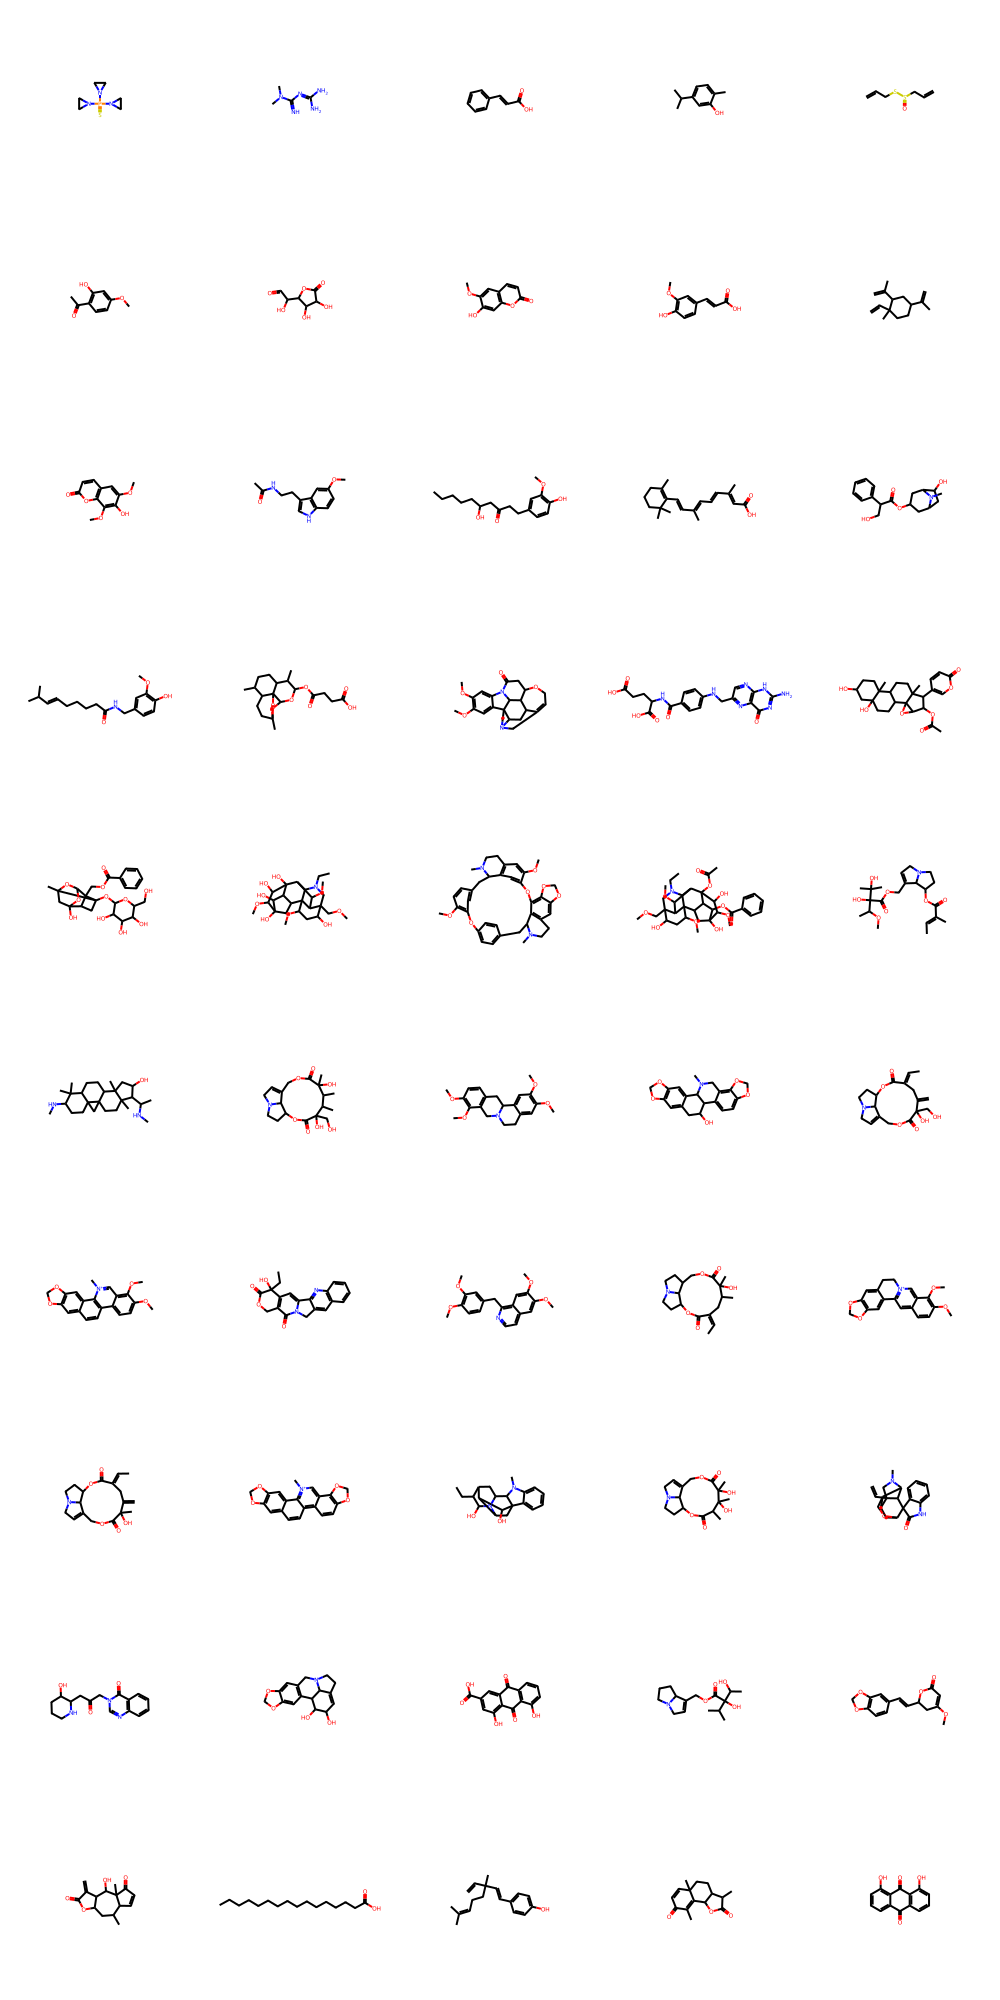

In [19]:
from rdkit.Chem import Draw
from rdkit import Chem

img=Draw.MolsToGridImage([Chem.MolFromSmiles(str(mol)) for mol in stand_data[:50]], molsPerRow=5,subImgSize=(200,200))    
img

## Стандартизация с помощью библиотеки RDKit

In [23]:
from rdkit.Chem import SDMolSupplier
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

In [24]:
molecules = [mol for mol in SDMolSupplier("DataCuration.sdf", sanitize=False)
             if mol is not None]
print(f'Количество молекул = {len(molecules)}')
print(molecules)

Количество молекул = 242
[<rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f140>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f1b0>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f220>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f290>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f300>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f370>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f3e0>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f450>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f4c0>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f530>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f5a0>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f610>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f680>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f6f0>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f760>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f7d0>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f840>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f8b0>, <rdkit.Chem.rdchem.Mol object at 0x7ff4eb87f920>, <rdkit.Chem.rdchem.Mol o

In [20]:
metals = [
    'Li', 'Na', 'K', 'Cu', 'Rb', 'Ag', 'Cs', 'Au', 'Fr', 
    'Be', 'Mg', 'Ca', 'Zn', 'Sr', 'Cd', 'Ba', 'Hg', 'Ra',
    'Al', 'Sc', 'Ga', 'Y', 'In', 'Tl', 
    'Ti', 'Ge', 'Zr', 'Sn', 'Hf', 'Pb', 'Rf', 
    'V', 'Nb', 'Sb', 'Ta', 'Bi', 'Db',
    'Cr', 'Mo', 'W', 'Po', 'Sg',
    'Mn', 'Tc', 'Re', 'Bh',
    'Fe', 'Ru', 'Os', 'Hs', 
    'Co', 'Rh', 'Ir', 'Mt', 
    'Ni', 'Pd', 'Pt', 
    'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 
    'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr'
              ]

def neutralize_atoms(mol):
    # Удаление радикалов
    for atom in mol.GetAtoms():
        atom.SetNumRadicalElectrons(0)
    pattern = Chem.MolFromSmarts("[+1!h0!$([*]~[-1,-2,-3,-4]),-1!$([*]~[+1,+2,+3,+4])]")
    at_matches = mol.GetSubstructMatches(pattern)
    at_matches_list = [y[0] for y in at_matches]
    if len(at_matches_list) > 0:
        for at_idx in at_matches_list:
            atom = mol.GetAtomWithIdx(at_idx)
            chg = atom.GetFormalCharge()
            hcount = atom.GetTotalNumHs()
            atom.SetFormalCharge(0)
            atom.SetNumExplicitHs(hcount - chg)
            atom.UpdatePropertyCache()
    return mol

In [21]:
def standardize_molecule(list_mol):
    new_list = []
    smiles_set = set()
    remove_mol = {"Salts, mixture": [], 'Inorganic': [], 'Metalloorganic': [], 'Problems': ''}
    for mol in list_mol:
        problems = Chem.DetectChemistryProblems(mol)
        for i in problems:
            remove_mol['Problems'] += str(i.Message())

        # Удаление водородов
        mol = Chem.RemoveHs(mol)
        
        # Нейтрализация молекул
        mol = neutralize_atoms(mol)
        
        # Приведение к каноническому виду
        smiles = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True, kekuleSmiles=True)

        # Удаление неорганических соединений
        if not mol.HasSubstructMatch(Chem.MolFromSmiles('C')):
            remove_mol['Inorganic'].append(Chem.MolToSmiles(mol))
            continue
        
        # Удаление солей, смесей
        if '.' in smiles:
            remove_mol['Salts, mixture'].append(smiles)
            continue
        
        # Удаление металлоорганике
        flag = False
        for atom in mol.GetAtoms():
            if atom.GetSymbol() in metals:
                flag = True
                break
        if flag:
            remove_mol['Metalloorganic'].append(smiles)
            continue

        # Нормализация стереохимии
        Chem.AssignStereochemistry(mol, force=True, cleanIt=True)
        
        
        # Удаление дубликатов
        if smiles not in smiles_set:
            smiles_set.add(smiles)
            new_list.append(mol)
        
    print(smiles_set)
    for key, value in remove_mol.items():
        print(f'Remove {key}: {len(value)}')
    return new_list

In [25]:
m1 = standardize_molecule(molecules)
len(m1)

{'CCCCC/C=C/C(=O)CCC1=CC=C(O)C(OC)=C1', 'C[Si](C)(C)O[Si](C)(C)O[Si](C)(C)C', 'N#CC(Cl)Cl', 'COC1=CC(C=O)=CC=C1O', 'NC1=C2C=CC=CC2=NC2=CC=C(O)C=C12', 'CC(=O)OCC1=CC=C2C=CC3=CC=CC4=CC=C1C2=C34', 'CNCC(=O)O', 'CC1=CC=C(N=NC2=CC=C(C)C(N)=C2)C=C1N', 'CC(C)OC(=O)C[C@@](O)(CC(=O)O)C(=O)O', 'CN1C=CC2=CC=C3C=CC4=CC=C(O)C=C4C3=C21', 'FC1=CC=C(CN2C3C4=CC=CC=C4C4=CC=CC=C4C32)C=C1', 'O=CNC1=NC(C2=CC=C([N+](=O)[O-])O2)=CS1', 'O=C(Cl)C1=CC=CC=C1[N+](=O)[O-]', 'COC1=CC(N)=C(OC)C=C1N', 'CC(=O)N(O)C1=CC=C(SC2=CC=CC=C2)C=C1', 'CN(CCCC(=O)C1=CC=CN=C1)N=O', 'OC1=CC=C(Cl)C=C1SC1=CC(Cl)=CC=C1O', 'CC(=O)NC1=CC=CC2=C1C1=CC=CC=C1C2', 'O=C(OOC(=O)C1=CC=CC=C1)C1=CC=CC=C1', 'NNC(N)=O', 'CN1C([N+](=O)[O-])=CN=C1COC(N)=O', 'O=C1CCC2=CC=C3C(=C12)C=CC1=CC=CC=C13', 'C1=CC2=C3C(=C1)C=CC1=C4C(=CC(=C13)C=C2)CC[C@H]1O[C@@H]41', 'ClC[C@H](Br)CBr', 'COC1=CC=C2C=C(C(C)C(=O)O)C=CC2=C1', 'NC1=CC=CC=C1N', 'N#C[C@@H](Cl)Br', 'CC1=CC=C2C(=C1)C=CC1=CC=CC=C12', 'C1=CNC=N1', 'O=[N+]([O-])C1=CC=C(C2=CC=C([N+](=O)[O-])C([N+](=O)[O-])=

224

Функция для сортировки списка молекул по молекулярной массе. Для облегчения визуального анализа, соединения схожие по молекулярной массе будут находиться в списке рядом.

In [26]:
def compare(left, right):
    left = Descriptors.ExactMolWt(left)
    right = Descriptors.ExactMolWt(right)
    if left < right:
        return -1
    elif left > right:
        return 1
    else:
        return 0

Сортируем список и визуализируем по 50 молекул на картинке.

In [27]:
from functools import cmp_to_key
a = sorted(m1, key=cmp_to_key(lambda item1, item2: compare(item1, item2)))

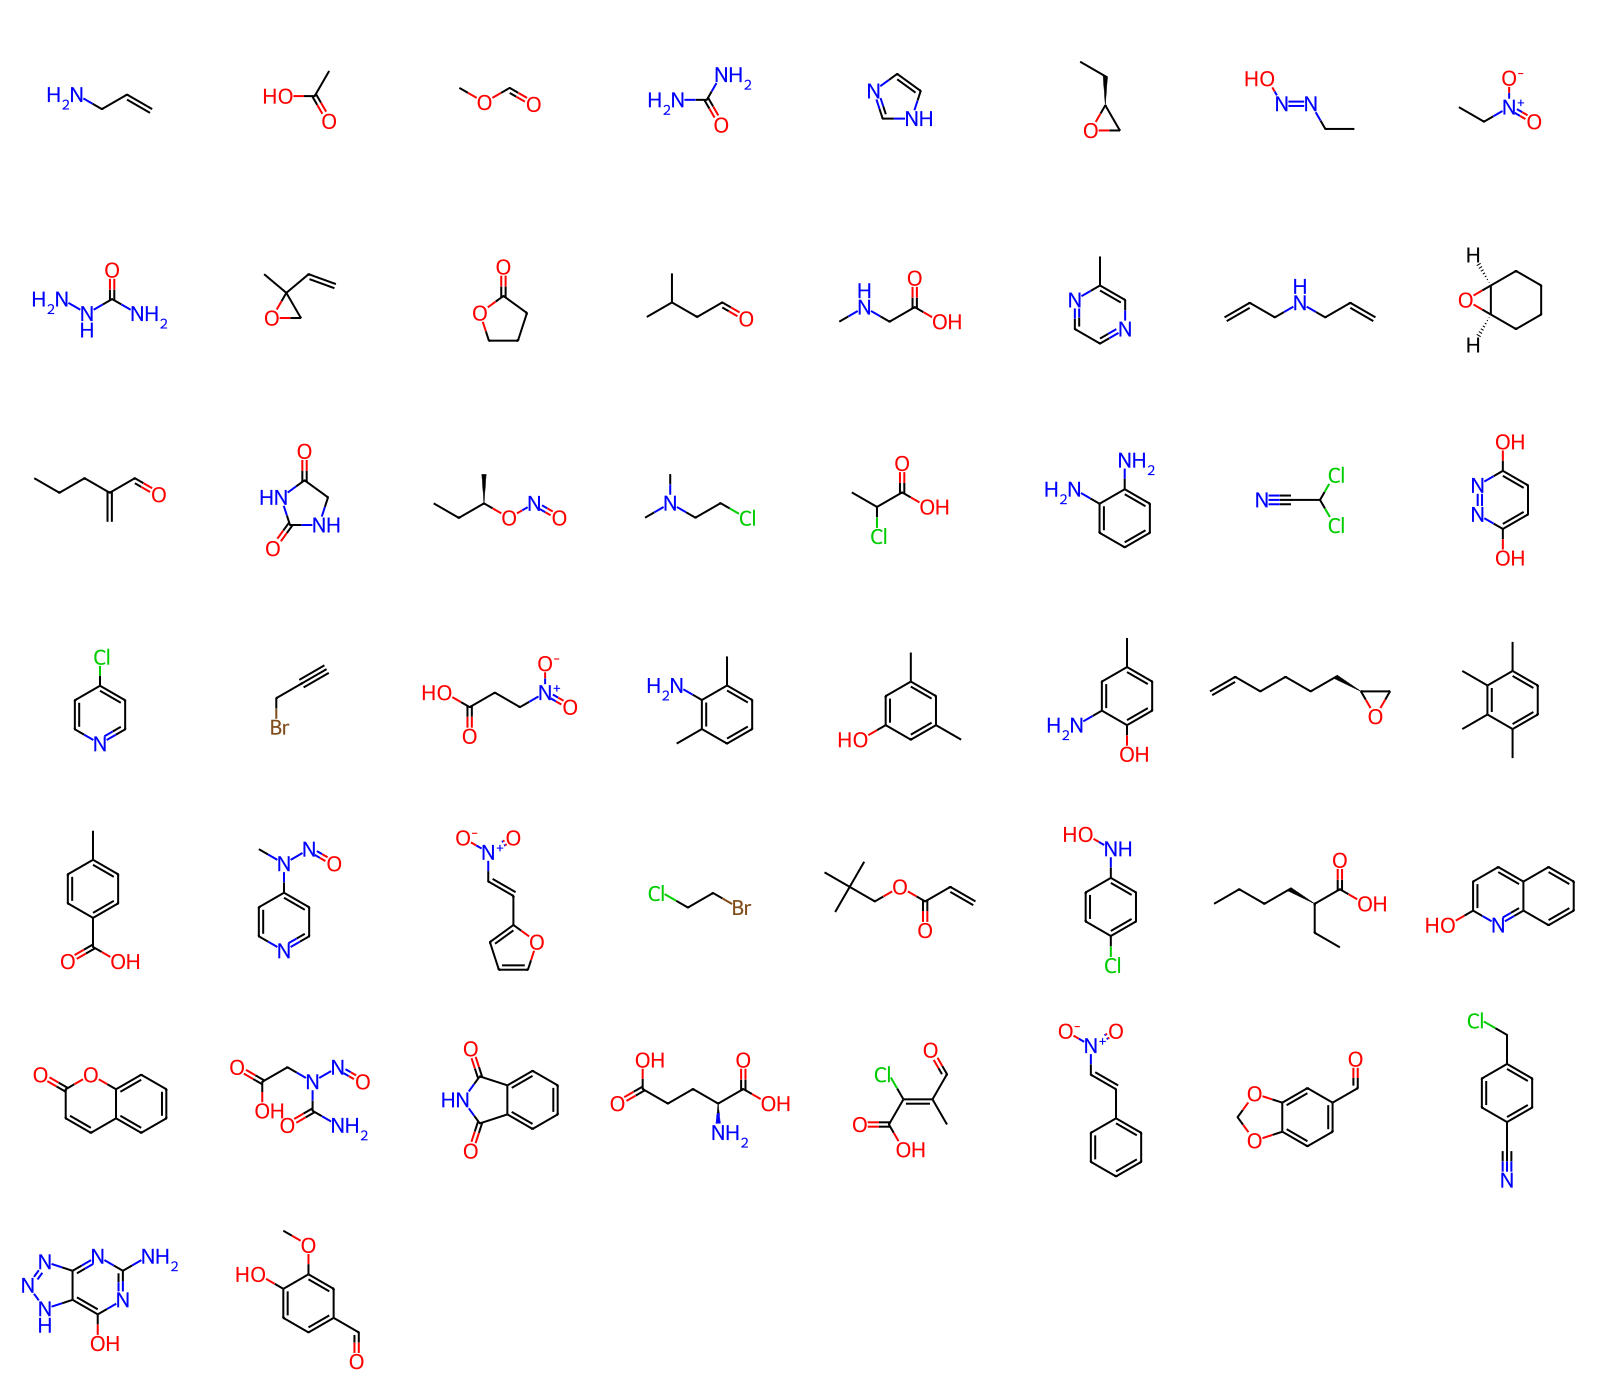

In [28]:
from rdkit.Chem import Draw

img=Draw.MolsToGridImage(a[:50], molsPerRow=8,subImgSize=(200,200))    
img